# Redes Neurais Convolucionais

Neste notebook, investigaremos as Redes Neurais Convolucionais (Convolutional Neural Networks, ou CNNs), uma classe de arquiteturas de redes neurais que se tornou o padrão para tarefas de visão computacional. Diferentemente de um Perceptron Multicamadas (MLP), que trata a entrada como um vetor unidimensional, as CNNs são projetadas para processar dados que possuem uma topologia de grade, como imagens.

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import MNIST
import torchvision
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## Arquitetura e Camadas de uma CNN

As Redes Neurais Convolucionais são compostas principalmente por dois tipos de operações fundamentais: **Convolução** e **Pooling**. Juntas, elas formam blocos de extração de características (feature extractors) que preservam e exploram a estrutura topológica dos dados.

### Convolução 2D (Conv2D)

A camada de convolução 2D (`nn.Conv2d` no PyTorch) é o bloco de construção principal para processamento de imagens. Em vez de conectar todos os neurônios de entrada aos de saída, aplicamos pequenos filtros (kernels) que deslizam (operação de convolução ou correlação cruzada) sobre a imagem.

Os principais hiperparâmetros de uma camada convolucional são:
- **Canais de Entrada ($C_{in}$):** O número de canais da imagem ou mapa de características de entrada. Por exemplo, uma imagem RGB possui $C_{in} = 3$.
- **Canais de Saída ($C_{out}$):** O número de filtros diferentes aplicados à entrada. Cada filtro gera um "mapa de características" (feature map) distinto na saída.
- **Tamanho do Kernel ($K$):** As dimensões espaciais do filtro (geralmente quadrado, como $3\times3$ ou $5\times5$).
- **Stride ($S$):** O passo com o qual o filtro desliza sobre a entrada. Um stride maior que 1 reduz as dimensões espaciais da saída.
- **Padding ($P$):** Adição de zeros (ou outros valores) às bordas da entrada antes de aplicar a convolução. Ajuda a controlar o tamanho espacial da saída e a preservar informações nas bordas.

A relação entre a dimensão espacial de entrada ($W_{in}$ ou $H_{in}$) e a de saída ($W_{out}$ ou $H_{out}$) em uma dimensão é dada por:

$$ W_{out} = \left\lfloor \frac{W_{in} - K + 2P}{S} \right\rfloor + 1 $$

Para uma entrada com formato $(N, C_{in}, H, W)$, onde $N$ é o tamanho do lote (batch size), a saída terá o formato $(N, C_{out}, H_{out}, W_{out})$.

In [15]:
# Exemplo de Conv2D
# Entrada: Lote de 1 imagem, 3 canais (RGB), 32x32 pixels
x_2d = torch.randn(1, 3, 32, 32)

# Definindo a camada Conv2D
conv2d = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
out_2d = conv2d(x_2d)

print(f"Shape da entrada Conv2D: {x_2d.shape}")
print(f"Shape da saída Conv2D: {out_2d.shape} -> (Batch, Canais_Out, Altura, Largura)")

Shape da entrada Conv2D: torch.Size([1, 3, 32, 32])
Shape da saída Conv2D: torch.Size([1, 16, 32, 32]) -> (Batch, Canais_Out, Altura, Largura)


### Outras Convoluções: Conv1D e Conv3D

Embora `Conv2D` seja ideal para imagens, dependendo da dimensionalidade dos dados, podemos utilizar:
- **Conv1D (`nn.Conv1d`):** Usado para dados sequenciais, como séries temporais ou sinais de áudio. O filtro desliza em apenas uma dimensão espacial.
- **Conv3D (`nn.Conv3d`):** Usado para dados volumétricos, como vídeos (onde a terceira dimensão é o tempo) ou ressonâncias magnéticas (3D espaciais). O filtro desliza nas três dimensões.

In [16]:
# Exemplo de Conv1D
# Entrada: Lote de 1 série temporal, 10 canais (ex: sensores), comprimento 50
x_1d = torch.randn(1, 10, 50)
conv1d = nn.Conv1d(in_channels=10, out_channels=20, kernel_size=5, stride=2)
out_1d = conv1d(x_1d)

print(f"Shape da entrada Conv1D: {x_1d.shape}")
print(f"Shape da saída Conv1D: {out_1d.shape} -> (Batch, Canais_Out, Comprimento_Out)\n")

Shape da entrada Conv1D: torch.Size([1, 10, 50])
Shape da saída Conv1D: torch.Size([1, 20, 23]) -> (Batch, Canais_Out, Comprimento_Out)



In [17]:
# Exemplo de Conv3D
# Entrada: Lote de 1 vídeo, 3 canais (RGB), 10 frames, 32x32 pixels
x_3d = torch.randn(1, 3, 10, 32, 32)
conv3d = nn.Conv3d(in_channels=3, out_channels=8, kernel_size=(3, 3, 3), stride=1, padding=1)
out_3d = conv3d(x_3d)

print(f"Shape da entrada Conv3D: {x_3d.shape}")
print(f"Shape da saída Conv3D: {out_3d.shape} -> (Batch, Canais_Out, Profundidade, Altura, Largura)")

Shape da entrada Conv3D: torch.Size([1, 3, 10, 32, 32])
Shape da saída Conv3D: torch.Size([1, 8, 10, 32, 32]) -> (Batch, Canais_Out, Profundidade, Altura, Largura)


### Camadas de Pooling

A operação de *Pooling* (agrupamento) é utilizada para reduzir as dimensões espaciais (largura e altura) dos mapas de características, diminuindo a quantidade de parâmetros, o custo computacional e ajudando a controlar o overfitting. Além disso, o pooling introduz uma invariância local à translação (pequenos deslocamentos na entrada não mudam a saída).

As operações de pooling mais comuns são:
- **Max Pooling (`nn.MaxPool2d`):** Seleciona o valor máximo em cada janela. É o mais utilizado pois retém as características mais proeminentes.
- **Average Pooling (`nn.AvgPool2d`):** Calcula a média dos valores na janela.

Da mesma forma que a convolução, o pooling possui parâmetros de tamanho de janela ($K$) e passo ($S$). Geralmente, não se utiliza padding em camadas de pooling e define-se $K=S$ (por exemplo, um Max Pooling $2\times2$ com stride $2$ divide a resolução espacial pela metade).

In [18]:
# Exemplo de Pooling
# Entrada: Lote de 1 imagem com 16 canais, 32x32 pixels
x_pool = torch.randn(1, 16, 32, 32)

# Definindo MaxPooling e AvgPooling
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

out_max = max_pool(x_pool)
out_avg = avg_pool(x_pool)

print(f"Shape da entrada Pooling: {x_pool.shape}")
print(f"Shape da saída MaxPool2D: {out_max.shape} -> Resolução caiu pela metade")
print(f"Shape da saída AvgPool2D: {out_avg.shape} -> Resolução caiu pela metade")

Shape da entrada Pooling: torch.Size([1, 16, 32, 32])
Shape da saída MaxPool2D: torch.Size([1, 16, 16, 16]) -> Resolução caiu pela metade
Shape da saída AvgPool2D: torch.Size([1, 16, 16, 16]) -> Resolução caiu pela metade


## Comparativo entre Redes Fully Connected e Convolucional

Para entender as vantagens das CNNs, vamos treinar e comparar dois modelos no dataset MNIST: um Perceptron Multicamadas tradicional e uma CNN. Enquanto a rede Fully Connected exige que a imagem seja 'achatada' num vetor 1D (perdendo a relação espacial entre pixels próximos), a CNN preserva o formato 2D, utilizando filtros que deslizam pela imagem. Isso permite que a rede aprenda a reconhecer padrões locais, como bordas e texturas, utilizando muito menos parâmetros e geralmente alcançando um desempenho superior.

Iniciamos preparando o dataset MNIST. Utilizaremos subconjuntos de 5.000 imagens para treino e 1.000 para validação. As imagens serão convertidas para tensores e normalizadas (média `0.1307`, desvio padrão `0.3081`) para otimizar a convergência do modelo.

In [19]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))
])

full_train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
full_val_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

train_indices = torch.arange(5000)
val_indices = torch.arange(1000)

train_subset = Subset(full_train_dataset, train_indices)
val_subset = Subset(full_val_dataset, val_indices)

batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

print(f"Tamanho do subset de treino: {len(train_subset)} imagens")
print(f"Tamanho do subset de validação: {len(val_subset)} imagens")
print(f"Número de batches no train_loader: {len(train_loader)}")

Tamanho do subset de treino: 5000 imagens
Tamanho do subset de validação: 1000 imagens
Número de batches no train_loader: 79


In [20]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate_model(model, val_loader, criterion):
    model.eval()  # Coloca o modelo em modo de avaliação
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_val_loss = val_loss / len(val_loader)
    accuracy = 100 * correct / total
    return avg_val_loss, accuracy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': []
    }
    
    for epoch in range(num_epochs):
        model.train()  # Modo de treinamento
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        # Loop de treinamento
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        avg_train_loss = running_train_loss / len(train_loader)
        train_accuracy = 100 * correct_train / total_train
        
        # Avaliação ao final da época
        avg_val_loss, val_accuracy = evaluate_model(model, val_loader, criterion)
        
        # Armazena as métricas
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_accuracy'].append(val_accuracy)
        
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {avg_val_loss:.4f}, "
              f"Train Acc: {train_accuracy:.2f}%, "
              f"Val Acc: {val_accuracy:.2f}%")
    
    print("Treinamento concluído.")
    return history

def plot_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot de Perda (Loss)
    ax1.plot(history['train_loss'], label='Perda de Treinamento')
    ax1.plot(history['val_loss'], label='Perda de Validação')
    ax1.set_title('Curvas de Perda')
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('Perda')
    ax1.legend()
    ax1.grid(True)

    # Plot de Acurácia
    if 'train_accuracy' in history:
        ax2.plot(history['train_accuracy'], label='Acurácia de Treinamento')
    ax2.plot(history['val_accuracy'], label='Acurácia de Validação')
    ax2.set_title('Curva de Acurácia')
    ax2.set_xlabel('Épocas')
    ax2.set_ylabel('Acurácia (%)')
    ax2.legend()
    ax2.grid(True)

    plt.show()

### Baseline: Fully Connected (MLP)

Nossa primeira abordagem será um Perceptron Multicamadas simples. A imagem de entrada `[1, 28, 28]` é "achatada" (flatten) para um vetor de 784 elementos, perdendo sua estrutura espacial 2D.

In [21]:
mlp_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

print(f"Modelo MLP - Número de parâmetros: {count_parameters(mlp_model):,}")

Modelo MLP - Número de parâmetros: 101,770


Epoch [1/10], Train Loss: 0.6779, Val Loss: 0.4161, Train Acc: 80.54%, Val Acc: 87.60%
Epoch [2/10], Train Loss: 0.2808, Val Loss: 0.3520, Train Acc: 91.98%, Val Acc: 89.80%
Epoch [3/10], Train Loss: 0.2126, Val Loss: 0.3130, Train Acc: 94.06%, Val Acc: 90.30%
Epoch [4/10], Train Loss: 0.1659, Val Loss: 0.2817, Train Acc: 95.44%, Val Acc: 91.20%
Epoch [5/10], Train Loss: 0.1278, Val Loss: 0.2888, Train Acc: 96.76%, Val Acc: 90.70%
Epoch [6/10], Train Loss: 0.1026, Val Loss: 0.2562, Train Acc: 97.54%, Val Acc: 92.00%
Epoch [7/10], Train Loss: 0.0926, Val Loss: 0.2421, Train Acc: 97.52%, Val Acc: 92.50%
Epoch [8/10], Train Loss: 0.0665, Val Loss: 0.2443, Train Acc: 98.54%, Val Acc: 92.90%
Epoch [9/10], Train Loss: 0.0489, Val Loss: 0.2403, Train Acc: 99.08%, Val Acc: 92.60%
Epoch [10/10], Train Loss: 0.0392, Val Loss: 0.2452, Train Acc: 99.28%, Val Acc: 92.90%
Treinamento concluído.


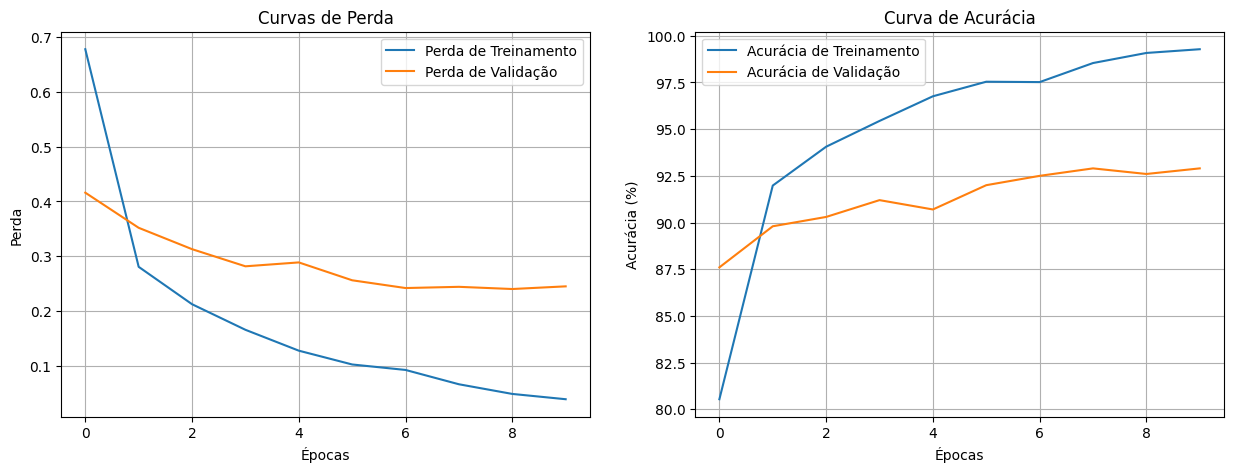

In [22]:
# Definindo o critério de perda e o otimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

# Treinando o modelo e coletando o histórico
mlp_history = train_model(mlp_model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

# Plotando as curvas de aprendizado
plot_curves(mlp_history)

### Modelo Convolucional (CNN)

Agora, implementaremos a CNN. Sua arquitetura utiliza camadas especializadas (`Conv2d`, `MaxPool2d`) para preservar e explorar a estrutura espacial das imagens, baseando-se nos princípios de **localidade de conexões** e **compartilhamento de parâmetros**.

In [23]:
cnn_model = nn.Sequential(
    # A entrada tem shape [N, 1, 28, 28]
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1), # [N, 16, 28, 28]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2), # Shape: [N, 16, 14, 14]
    
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), # [N, 32, 14, 14]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2), # [N, 32, 7, 7]
    
    nn.Flatten(), # [N, 32*7*7] = [N, 1568]
    nn.Linear(32 * 7 * 7, 10) # [N, 10]
)

# Contagem de parâmetros
print(f"Modelo CNN - Número de parâmetros: {count_parameters(cnn_model):,}")

Modelo CNN - Número de parâmetros: 20,490


Epoch [1/10], Train Loss: 0.7687, Val Loss: 0.3268, Train Acc: 79.10%, Val Acc: 89.60%
Epoch [2/10], Train Loss: 0.2249, Val Loss: 0.2211, Train Acc: 93.58%, Val Acc: 92.60%
Epoch [3/10], Train Loss: 0.1460, Val Loss: 0.1490, Train Acc: 95.98%, Val Acc: 95.30%
Epoch [4/10], Train Loss: 0.1054, Val Loss: 0.1433, Train Acc: 97.04%, Val Acc: 95.00%
Epoch [5/10], Train Loss: 0.0800, Val Loss: 0.1320, Train Acc: 97.70%, Val Acc: 95.60%
Epoch [6/10], Train Loss: 0.0665, Val Loss: 0.1174, Train Acc: 98.08%, Val Acc: 96.40%
Epoch [7/10], Train Loss: 0.0514, Val Loss: 0.1139, Train Acc: 98.58%, Val Acc: 96.30%
Epoch [8/10], Train Loss: 0.0480, Val Loss: 0.1467, Train Acc: 98.82%, Val Acc: 95.60%
Epoch [9/10], Train Loss: 0.0436, Val Loss: 0.1030, Train Acc: 98.88%, Val Acc: 96.40%
Epoch [10/10], Train Loss: 0.0280, Val Loss: 0.1103, Train Acc: 99.30%, Val Acc: 96.40%
Treinamento concluído.


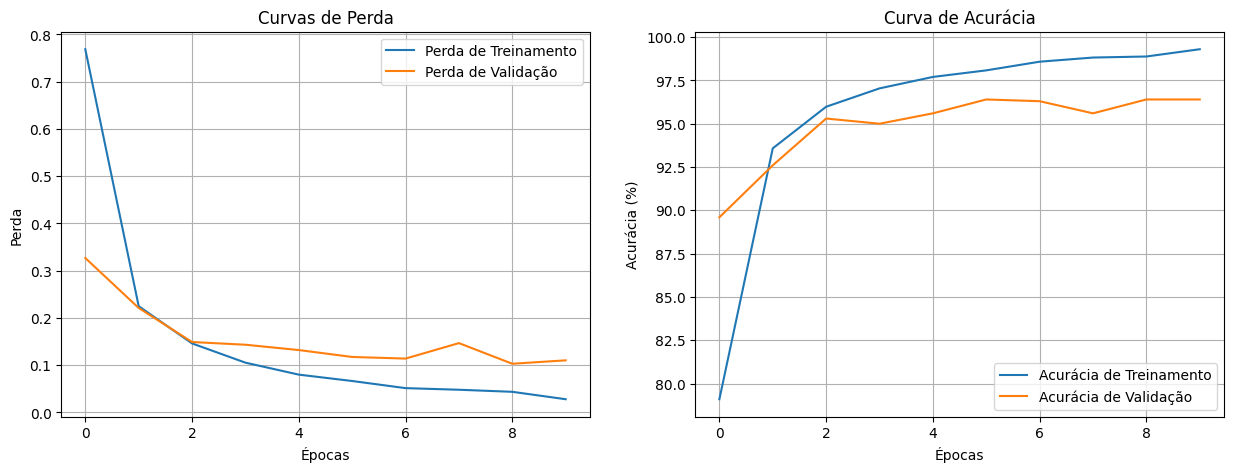

In [24]:
# Definindo o critério de perda e o otimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

# Treinando o modelo e coletando o histórico
cnn_history = train_model(cnn_model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

# Plotando as curvas de aprendizado
plot_curves(cnn_history)

### Conclusão

Ao analisarmos os resultados no dataset MNIST, podemos notar diferenças fundamentais entre a arquitetura Fully Connected e a Rede Neural Convolucional:

1. **Número de Parâmetros:** A MLP (FC) geralmente exige muitos parâmetros, pois cada neurônio se conecta a todos os pixels da entrada (achatada). A CNN utiliza **compartilhamento de parâmetros** através dos filtros convolucionais, reduzindo drasticamente o tamanho do modelo.
2. **Localidade Espacial:** A CNN preserva a estrutura de grade 2D da imagem e explora a **localidade das conexões** (pixels próximos formam bordas/texturas). A FC destrói essa relação ao utilizar o `Flatten` logo no início.
3. **Generalização:** Devido a essas propriedades e à invariância à translação fornecida pelo Pooling, a CNN atinge maior acurácia de validação com menos parâmetros em tarefas de visão computacional.

## O Desafio do CIFAR-10

Após testarmos nossos modelos no clássico MNIST, vamos agora aumentar a complexidade utilizando o dataset **CIFAR-10**.

Diferente do MNIST (imagens em escala de cinza 28x28), o CIFAR-10 contém imagens coloridas (RGB) com resolução de 32x32 pixels, representando objetos do mundo real em 10 classes distintas (aviões, carros, pássaros, gatos, etc.). Essa mudança nos permitirá ver na prática como a CNN lida com a profundidade dos canais ($C_{in} = 3$) e aprende características mais ricas.

### Carregamento e Pré-processamento do Dataset CIFAR-10

O dataset CIFAR-10 é composto por 60.000 imagens coloridas de 32x32 pixels, distribuídas em 10 classes. Aplicaremos uma sequência de transformações (`transforms.Compose`):

1.  **`transforms.ToTensor()`**: Converte as imagens para tensores do PyTorch.
2.  **`transforms.Normalize()`**: Normaliza os tensores, escalando os valores dos pixels para o intervalo [-1, 1]. A equação de normalização para um canal de um pixel $x$ é:

    $$x_{norm} = \frac{x - \mu}{\sigma}$$

    Onde $\mu$ é a média e $\sigma$ é o desvio padrão.

In [25]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 64


In [26]:

train_dataset = torchvision.datasets.CIFAR10(root='./data/CIFAR10', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)


100%|██████████| 170M/170M [00:52<00:00, 3.27MB/s] 
/Users/gilcesarf/git/repositories/imd/imd1114-202601/deep-learning/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [27]:

val_dataset = torchvision.datasets.CIFAR10(root='./data/CIFAR10', train=False, download=True, transform=transform)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


In [28]:

# Classes do CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

### Visualização de Amostras de Dados

É uma boa prática inspecionar visualmente algumas amostras do dataset para garantir que os dados foram carregados e processados corretamente. O código a seguir extrai um lote (*batch*) de imagens do `train_loader` e as exibe.

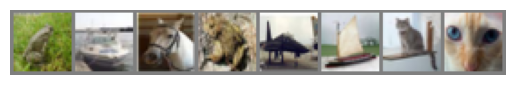

frog  ship  horse frog  plane ship  cat   cat  


In [29]:
def imshow(img):
    img = img / 2 + 0.5     # desnormalizar
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

### Definição da Arquitetura da CNN

Dividiremos o modelo em duas partes principais:

* **Extrator de Features (`features`)**: Um bloco sequencial contendo as camadas convolucionais (`Conv2d`), de ativação (`ReLU`) e de pooling (`MaxPool2d`), responsável por aprender e extrair características hierárquicas das imagens.
* **Classificador (`classifier`)**: Um segundo bloco sequencial, que recebe o mapa de features achatado (*flattened*) e utiliza camadas totalmente conectadas (`Linear`) para realizar a classificação final.

In [30]:
class CIFARClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        # Entrada: (3, 32, 32)
        self.features = nn.Sequential(
            # Bloco 1 -> (32, 32, 32)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (32, 16, 16)

            # Bloco 2 -> (64, 16, 16)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (64, 8, 8)

            # Bloco 3 -> (128, 8, 8)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (128, 4, 4)
        )
        
        # 128 * 4 * 4 = 2048
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [31]:
model_cifar = CIFARClassifier()

x = torch.randn(1, 3, 32, 32)
out = model_cifar(x)
print(out.shape)

torch.Size([1, 10])


Epoch [1/10], Train Loss: 1.3944, Val Loss: 1.0887, Train Acc: 49.38%, Val Acc: 62.12%
Epoch [2/10], Train Loss: 1.0496, Val Loss: 0.8989, Train Acc: 62.90%, Val Acc: 68.71%
Epoch [3/10], Train Loss: 0.9164, Val Loss: 0.8362, Train Acc: 67.93%, Val Acc: 70.66%
Epoch [4/10], Train Loss: 0.8321, Val Loss: 0.7588, Train Acc: 71.05%, Val Acc: 73.55%
Epoch [5/10], Train Loss: 0.7657, Val Loss: 0.7733, Train Acc: 73.54%, Val Acc: 72.86%
Epoch [6/10], Train Loss: 0.7065, Val Loss: 0.7179, Train Acc: 75.45%, Val Acc: 75.16%
Epoch [7/10], Train Loss: 0.6543, Val Loss: 0.6906, Train Acc: 77.29%, Val Acc: 75.99%
Epoch [8/10], Train Loss: 0.6059, Val Loss: 0.6491, Train Acc: 78.88%, Val Acc: 77.50%
Epoch [9/10], Train Loss: 0.5641, Val Loss: 0.7096, Train Acc: 80.45%, Val Acc: 76.34%
Epoch [10/10], Train Loss: 0.5232, Val Loss: 0.6827, Train Acc: 81.63%, Val Acc: 77.09%
Treinamento concluído.


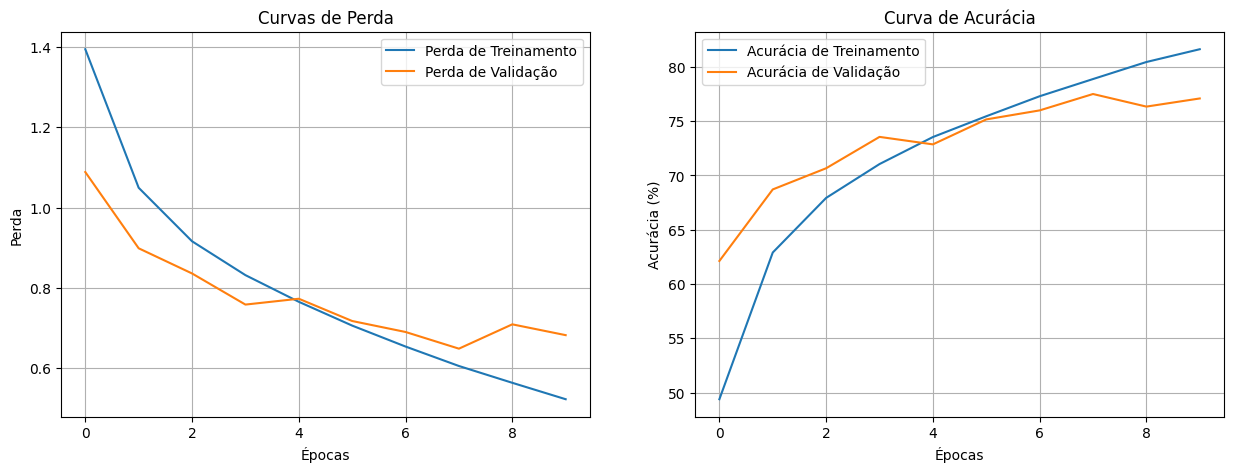

In [32]:
# Definindo o critério de perda e o otimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cifar.parameters(), lr=0.001)

# Treinando o modelo e coletando o histórico
cifar_history = train_model(model_cifar, train_loader, val_loader, criterion, optimizer, num_epochs=10)

# Plotando as curvas de aprendizado
plot_curves(cifar_history)

## Exercícios

### Exercício 1

Neste exercício, você deverá investigar qual combinação de blocos convolucionais produz melhor desempenho no CIFAR-10. Em vez de implementar apenas uma arquitetura fixa, construa uma classe herdando de `nn.Module` e organize o modelo em duas partes: um `feature_extractor`, contendo as camadas convolucionais, ativações, normalizações e pooling; e um `classifier`, contendo as camadas finais de classificação, como `Flatten`, `Linear` e `Dropout`. Explore diferentes configurações variando o número de blocos, a quantidade de filtros (canais), o uso de `BatchNorm2d`, o uso de uma ou duas convoluções por bloco, a taxa de `Dropout`, além de parâmetros estruturais como `stride`, `kernel_size` e estratégias de redução espacial.

Treine pelo menos três arquiteturas no CIFAR-10, compare loss e acurácia de treino e validação, e identifique qual configuração apresentou melhor desempenho e maior estabilidade, discutindo brevemente possíveis sinais de overfitting e o impacto das escolhas arquiteturais.

### Exercício 2

Neste exercício, o foco não será apenas a arquitetura, mas o comportamento do treinamento. Mantendo uma arquitetura base fixa para o CIFAR-10, investigue como diferentes escolhas de otimização e regularização afetam a convergência e a generalização do modelo. Utilize a mesma rede e varie aspectos como otimizador (por exemplo, SGD vs Adam), taxa de aprendizado, uso de weight decay, presença de Dropout e aplicação de data augmentation nas imagens de entrada, mantendo controle sobre as demais variáveis para isolar os efeitos.

Treine o modelo sob diferentes configurações e compare as curvas de loss e acurácia ao longo das épocas, analisando estabilidade, velocidade de convergência e gap entre treino e validação. Discuta como cada escolha influencia o processo de aprendizado e qual combinação produziu melhor equilíbrio entre desempenho e generalização.